In [1]:
!pip install awswrangler -q
!pip install optbinning -q
!pip install lightgbm
!pip install xgboost
!pip install xgboost --prefer-binary
!pip install catboos

  error: subprocess-exited-with-error
  
  × installing build dependencies for scs did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/20.7 MB ? eta -:--:--
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 165.1 MB/s  0:00:00
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Installing backend dependencies: started
        Installing backend dependencies: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'error'
        error: subprocess-exited-with-error
      
        × Preparing metadata (pyproject.toml) did not run successfully.
        │ exit code: 1
        ╰─> [19 lines of output]
            + /home/

In [4]:
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from optbinning import BinningProcess
import shutil
from warnings import simplefilter
simplefilter(action = "ignore") #, category = FutureWarning

pd.set_option('display.max_rows', 500)
from sklearn.preprocessing import LabelEncoder

In [32]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/RENTA_ALTA'

df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202602.txt'.format(bucket_name, model_prefix ), sep= '|')



#s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PN/RENTA_ALTA/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202512.txt


In [5]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/RENTA_ALTA'

df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202512.txt'.format(bucket_name, model_prefix ), sep= '|')
df_2 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202601.txt'.format(bucket_name, model_prefix ), sep= '|')
df_3 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202602.txt'.format(bucket_name, model_prefix ), sep= '|')
df_4 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202511.txt'.format(bucket_name, model_prefix ), sep= '|')
df_5 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PN-RentaAlta_202510.txt'.format(bucket_name, model_prefix ), sep= '|')
#df_6 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202601.txt'.format(bucket_name, model_prefix ), sep= '|')
#df_7 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202602.txt'.format(bucket_name, model_prefix ), sep= '|')
df_final = pd.concat([df_1,df_2, df_3,df_4,df_5], ignore_index=True)

In [33]:
len(df_1)

236819

In [34]:
df_final= df_1

In [35]:
df_final.variable1.value_counts()

variable1
0                  236159
AUTOMATICA            526
SEMI AUTOMATICA       104
MANUAL                 30
Name: count, dtype: int64

In [36]:
df_final.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_nueva_alerta,score,orden,variable1,variable2,variable3
0,202602,4AD8FC64A58F119B09EADD72C7E83E1F2195FE95DD727D...,13163643,plaft_pj_minorista,20260521,P2,0,0.941575,1,0,NaN,NaN
1,202602,E634DDA71CC2CF6B2BA87379B887DD6CCA3773E62E0BF1...,8821278,plaft_pj_minorista,20260521,P2,0,0.935372,2,0,NaN,NaN
2,202602,38FA396C019FA4F3A76DD1818031887432FB8E89A92CC5...,13889861,plaft_pj_minorista,20260521,P2,0,0.934291,3,0,NaN,NaN
3,202602,8D6B133276F6722B27575C907C236243164FD1F3356B24...,5680640,plaft_pj_minorista,20260521,P2,0,0.933269,4,0,NaN,NaN
4,202602,F7569F5678628E95AA398221907C7849AC22BD56CD8B8E...,9530833,plaft_pj_minorista,20260521,P2,0,0.933109,5,0,NaN,NaN


In [37]:
df_res = (
    df_final
    .groupby(['grupo_alerta', 'codmes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_alerta', columns='codmes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

print(df_res)

codmes        202602   TOTAL
grupo_alerta                
P5            201915  201915
P4             33095   33095
P3              1731    1731
P2                78      78


In [10]:
df_res = (
    df_final
    .loc[df_final['grupo_corte_nueva_alerta'] != '0']
    .groupby(['grupo_alerta', 'codmes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_alerta', columns='codmes', values='cantidad')
    .fillna(0)
    .astype(int)
)
df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)
print(df_res)

codmes        202605   TOTAL
grupo_alerta                
P5            203200  203200
P4             32332   32332
P3              1801    1801
P2                96      96


In [10]:
import pandas as pd

# === Tu pivot original (cantidades) ===
df_res = (
    df_final
    .groupby(['grupo_alerta', 'codmes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_alerta', columns='codmes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

# === PORCENTAJES POR MES (suman 100% por columna / por mes) ===
df_months = df_res.iloc[:, :-1]                     # todas las columnas de meses (sin TOTAL)
month_totals = df_months.sum(axis=0)                # total por cada mes

df_pct = (df_months.div(month_totals, axis=1) * 100).round(1)
df_pct = df_pct.astype(str) + '%'

# Renombrar columnas para que quede claro
df_pct.columns = [f'{col} %' for col in df_pct.columns]

# === Mostrar resultados ===
print("=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===")
print(df_res)

print("\n=== PORCENTAJES por mes (cada columna suma 100%) ===")
print(df_pct)



=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===
codmes        202603   TOTAL
grupo_alerta                
P4+P5         236623  236623
P2               148     148
P1               128     128
P3               111     111

=== PORCENTAJES por mes (cada columna suma 100%) ===
             202603 %
grupo_alerta         
P4+P5           99.8%
P2               0.1%
P1               0.1%
P3               0.0%


In [11]:
df_final_alerta= df_final[(df_final.variable1 !='SIN_INFO')]

In [12]:
#test_data_0825_alerta_1= test_data_0825_alerta[(test_data_0825_alerta.variable1 !=0)]

In [13]:
import pandas as pd

# === Tu pivot original (cantidades) ===
df_res = (
    df_final_alerta
    .groupby(['grupo_alerta', 'codmes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_alerta', columns='codmes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

# === PORCENTAJES POR MES (suman 100% por columna / por mes) ===
df_months = df_res.iloc[:, :-1]                     # todas las columnas de meses (sin TOTAL)
month_totals = df_months.sum(axis=0)                # total por cada mes

df_pct = (df_months.div(month_totals, axis=1) * 100).round(1)
df_pct = df_pct.astype(str) + '%'

# Renombrar columnas para que quede claro
df_pct.columns = [f'{col} %' for col in df_pct.columns]

# === Mostrar resultados ===
print("=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===")
print(df_res)

print("\n=== PORCENTAJES por mes (cada columna suma 100%) ===")
print(df_pct)

=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===
codmes        202603  TOTAL
grupo_alerta               
P4+P5            276    276
P2               148    148
P1               128    128
P3               111    111

=== PORCENTAJES por mes (cada columna suma 100%) ===
             202603 %
grupo_alerta         
P4+P5           41.6%
P2              22.3%
P1              19.3%
P3              16.7%


In [32]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.num_documento,
        a.codunico,
        date_format(
            date_parse(CAST(a.mes_base AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.mes_base AS INTEGER) AS codmes

    

    FROM d_perm_aws.ds_alertplaft_mdl a
    WHERE a.mes_base between '202508' and  '202603' 
      AND a.subsegmento = 'Renta Alta'
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2
)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target_m
FROM pd a
LEFT JOIN target b
    ON a.codunico = b.codunico
 AND cast(a.codmes as varchar) = b.periodo_alerta
-- AND codmes_lag1 = b.periodo_alerta
;"""
df_dataset = wr.athena.read_sql_query(query, database = 'disc_comercial', ctas_approach=False)
df_dataset.head()

CPU times: user 6.8 s, sys: 672 ms, total: 7.48 s
Wall time: 24.1 s


,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,target_m
0,3E651D5D1551B7E1722E6551219EA9AA4FCF3548C277BF...,0009305743,202509,202508,<NA>,0
1,7B0998DAFFAF9A93E01A16EA418D6D8E5106351D3E6322...,0012652678,202510,202509,<NA>,0
2,6F504ACD72BFB27827D6CEDFA893429E5DF309414A2D52...,0014602221,202509,202508,<NA>,0
3,4394095301AC3E126045D583B39E663CEC310FB5943B02...,0009904444,202510,202509,<NA>,0
4,45D874A72FB006E3237886E4DC00092FE619C710442875...,0009149419,202511,202510,<NA>,0


In [33]:
df_dataset.target_m.value_counts()

target_m
0    2032142
1        419
Name: count, dtype: Int64

In [34]:
df_dataset.codmes.value_counts()

codmes
202601    268532
202512    265553
202511    262442
202510    255496
202509    254333
202508    252351
202603    237020
202602    236834
Name: count, dtype: Int64

In [40]:
df_final=df_1

In [41]:
df_final.codmes.value_counts()

codmes
202603    237010
Name: count, dtype: int64

In [42]:
import pandas as pd

# Aseguramos tipos consistentes
df_final['codmes'] = df_final['codmes'].astype(str)
df_dataset['codmes'] = df_dataset['codmes'].astype(str)

df_final['codunico'] = pd.to_numeric(df_final['codunico'], errors='coerce').astype('Int64')
df_dataset['codunico'] = pd.to_numeric(df_dataset['codunico'], errors='coerce').astype('Int64')

# 1. Cross join parcial (o merge sin condición de mes primero)
df_4_temp = pd.merge(
    df_final,
    df_dataset,
    on=['num_documento', 'codunico'],
    how='left',
    suffixes=('_final', '_dataset')
)

# 2. Filtramos solo las filas donde codmes_dataset >= codmes_final
df_4 = df_4_temp[
    df_4_temp['codmes_dataset'] >= df_4_temp['codmes_final']
].copy()

# 3. (Opcional) Si hay múltiples matches por cliente-mes, puedes quedarte con el primero o el más cercano
# Ejemplo: ordenar por diferencia de mes y quedarte con el menor (más cercano al actual)
df_4['mes_diff'] = pd.to_numeric(df_4['codmes_dataset']) - pd.to_numeric(df_4['codmes_final'])

# Ordenar por cliente + mes_diff ascendente (el más cercano primero)
df_4 = df_4.sort_values(['num_documento', 'codunico', 'mes_diff'])

# Opcional: quedarte solo con el match más cercano por cada fila de df_final
df_4 = df_4.drop_duplicates(subset=['num_documento', 'codunico', 'codmes_final'], keep='first')

# Limpiar columnas innecesarias si quieres
df_4 = df_4.drop(columns=['mes_diff'], errors='ignore')

print("=== df_4: join donde codmes_dataset >= codmes_final ===")
print(df_4.head(10))
print(f"\nForma final: {df_4.shape}")

=== df_4: join donde codmes_dataset >= codmes_final ===
        codmes_final                                      num_documento  \
1342501       202603  00002B9749A23E5B944049A6896567E71789A01E0F131E...   
77091         202603  0000552D82A2542C33F6DEB8142D8DCB06428B93CCBA62...   
1308630       202603  00029B59B23A631F0A47BBB300D97692C97A454416E419...   
947098        202603  0002EB4C6CD04DF1164216E70D57924CA45A451F889560...   
624994        202603  0002F776172B5F7A4A62494C14A117A814B0BA2271B5A6...   
568156        202603  00032F76902248827EFE6719C535512728875FD454EF9C...   
1065923       202603  00033C1C74B7EF56D662722E5A21643876706A6FBE882A...   
1102163       202603  00037F18A47FBB892C199FA1D21CA5C4BBF0BDEC0ADD1F...   
513444        202603  0003C732A830AA0B8D303E1C48E266764C9ACAF4A762B3...   
790088        202603  000484E840060F3A6CED2D52DF85DB8674F403CF867B4C...   

         codunico              modelo  fec_replica grupo_alerta  \
1342501    697391  plaft_pj_minorista     20260427 

In [43]:
df_dataset['codunico'] = pd.to_numeric(df_dataset['codunico'], errors='coerce').astype('Int64')

df_4 = pd.merge(
    df_final, 
    df_dataset, 
    left_on=['num_documento' 'codunico','codmes'], 
    right_on=['num_documento', 'codunico','codmes'], 
    how='inner'
)

ValueError: len(right_on) must equal len(left_on)

In [44]:
df_4.head()

,codmes_final,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_nueva_alerta,score,orden,variable1,variable2,variable3,codmes_lag1,codmes_dataset,tipo_alerta_n2,target_m
1342501,202603,00002B9749A23E5B944049A6896567E71789A01E0F131E...,697391,plaft_pj_minorista,20260427,P4+P5,0,0.131114,235307,SIN_INFO,NaN,NaN,202604,202603,<NA>,0
77091,202603,0000552D82A2542C33F6DEB8142D8DCB06428B93CCBA62...,11297637,plaft_pj_minorista,20260427,P4+P5,0,0.823407,12335,SIN_INFO,NaN,NaN,202604,202603,<NA>,0
1308630,202603,00029B59B23A631F0A47BBB300D97692C97A454416E419...,20011116,plaft_pj_minorista,20260427,P4+P5,0,0.151819,229232,SIN_INFO,NaN,NaN,202604,202603,<NA>,0
947098,202603,0002EB4C6CD04DF1164216E70D57924CA45A451F889560...,10520892,plaft_pj_minorista,20260427,P4+P5,0,0.271785,162861,SIN_INFO,NaN,NaN,202604,202603,<NA>,0
624994,202603,0002F776172B5F7A4A62494C14A117A814B0BA2271B5A6...,9432763,plaft_pj_minorista,20260427,P4+P5,0,0.372235,105440,SIN_INFO,NaN,NaN,202604,202603,<NA>,0


In [45]:
df_7= df_4[(df_4.variable1 !='SIN_INFO')]

In [46]:
import pandas as pd

# 1. Agrupación por mes y grupo_alerta
df_res = (
    df_7
    .groupby(['codmes_final', 'grupo_alerta'], as_index=False)
    .agg(
        cantidad_casos=('num_documento', 'count'),
        cantidad_positivos=('target_m', 'sum')
    )
)

# 2. Calcular % positivos dentro del grupo-mes (tasa interna, opcional pero útil)
df_res['%_positivos_grupo'] = (
    (df_res['cantidad_positivos'] / df_res['cantidad_casos'] * 100)
    .round(1)
).astype(str) + '%'

# 3. Total de positivos por mes (solo target_m == 1)
total_positivos_por_mes = df_res.groupby('codmes_final')['cantidad_positivos'].sum().rename('total_positivos_mes')

# 4. Unir y calcular % participación en positivos del mes (suma 100% por mes)
df_res = df_res.merge(total_positivos_por_mes, on='codmes_final', how='left')

df_res['%_participacion_positivos_mes'] = (
    (df_res['cantidad_positivos'] / df_res['total_positivos_mes'] * 100)
    .round(1)
).astype(str) + '%'

# 5. Ordenamiento: por mes ascendente + dentro del mes por cantidad_positivos descendente
df_res = df_res.sort_values(
    ['codmes_final', 'cantidad_positivos'],
    ascending=[True, False]
)

# Columnas finales (como pediste: mes, grupo, casos, positivos, % participación en positivos)
df_final_ordenado = df_res[[
    'codmes_final',
    'grupo_alerta',
    'cantidad_casos',
    'cantidad_positivos',
    '%_participacion_positivos_mes'
]]

# Mostrar
print("=== DataFrame ordenado por mes (asc) y dentro de cada mes por cantidad_positivos (desc) ===")
print("El % participación suma 100% por mes considerando SOLO los casos positivos")
print(df_final_ordenado)

# Vista pivot para verificar que cada mes suma ~100% en positivos
pivot_positivos = df_res.pivot(
    index='grupo_alerta',
    columns='codmes_final',
    values='%_participacion_positivos_mes'
)

print("\n=== Pivot: % participación en positivos por mes (cada columna suma ~100%) ===")
print(pivot_positivos)

=== DataFrame ordenado por mes (asc) y dentro de cada mes por cantidad_positivos (desc) ===
El % participación suma 100% por mes considerando SOLO los casos positivos
  codmes_final grupo_alerta  cantidad_casos  cantidad_positivos  \
1       202603           P2             148                  32   
0       202603           P1             128                  25   
3       202603        P4+P5             276                  24   
2       202603           P3             111                  14   

  %_participacion_positivos_mes  
1                         33.7%  
0                         26.3%  
3                         25.3%  
2                         14.7%  

=== Pivot: % participación en positivos por mes (cada columna suma ~100%) ===
codmes_final 202603
grupo_alerta       
P1            26.3%
P2            33.7%
P3            14.7%
P4+P5         25.3%


In [47]:
df_final_ordenado

,codmes_final,grupo_alerta,cantidad_casos,cantidad_positivos,%_participacion_positivos_mes
1,202603,P2,148,32,33.7%
0,202603,P1,128,25,26.3%
3,202603,P4+P5,276,24,25.3%
2,202603,P3,111,14,14.7%


Matriz de Confusión:
[[236639    276]
 [    32     63]]


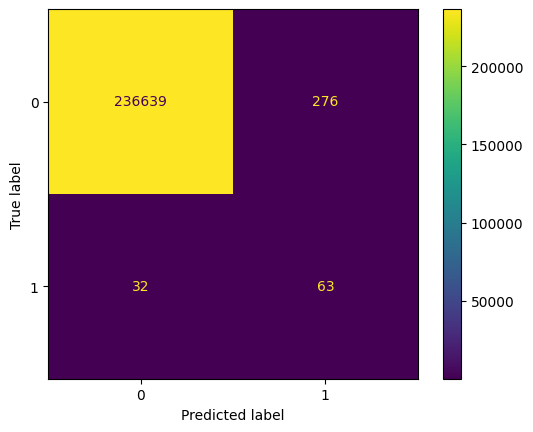

In [48]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Supongamos que quieres usar 0.5 como umbral
umbral = 0.9875
df_4['prediccion'] = (df_4['score'] >= umbral).astype(int)

# Matriz de confusión
y_true = df_4['target_m']
y_pred = df_4['prediccion']

cm = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(cm)

# Mostrar gráfica (opcional)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()


In [33]:
df_4.variable1.value_counts()

variable1
SIN_INFO           806173
AUTOMATICA           2530
MANUAL                984
SEMI AUTOMATICA       279
Name: count, dtype: int64

In [48]:
df_4[['grupo_corte_nueva_alerta','codmes']].value_counts()

grupo_corte_nueva_alerta  codmes
0                         202512    165203
                          202511    163394
                          202510    161921
                          202509    159962
                          202508    158565
1                         202508       203
                          202512       193
                          202509       186
                          202511       178
                          202510       161
Name: count, dtype: int64

In [34]:
df_5= df_4[(df_4.variable1 !='SIN_INFO')]

In [35]:
df_5.codmes.value_counts()

codmes
202510    1459
202509     814
202508     560
202512     510
202511     450
Name: count, dtype: int64

In [36]:
df_res = (
    df_5
    .groupby("grupo_alerta")
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)
df_res

,grupo_alerta,cantidad_casos,suma_target_m
0,P1,752,278
1,P2,760,72
2,P3,770,41
3,P4+P5,1511,31


In [42]:
!pip install seaborn

    codmes grupo_alerta  cantidad_casos  suma_target_m  efectividad_pct
0   202508           P1             488             80            16.39
1   202508           P2             890             14             1.57
2   202508           P3            3633             13             0.36
3   202508        P4+P5          153757              9             0.01
4   202509           P1             515             62            12.04
5   202509           P2             935             18             1.93
6   202509           P3            3600             13             0.36
7   202509        P4+P5          155098              4              0.0
8   202510           P1             597             99            16.58
9   202510           P2            1024             18             1.76
10  202510           P3            3746              2             0.05
11  202510        P4+P5          156715             10             0.01
12  202511           P1             410             31          

TypeError: Image data of dtype object cannot be converted to float

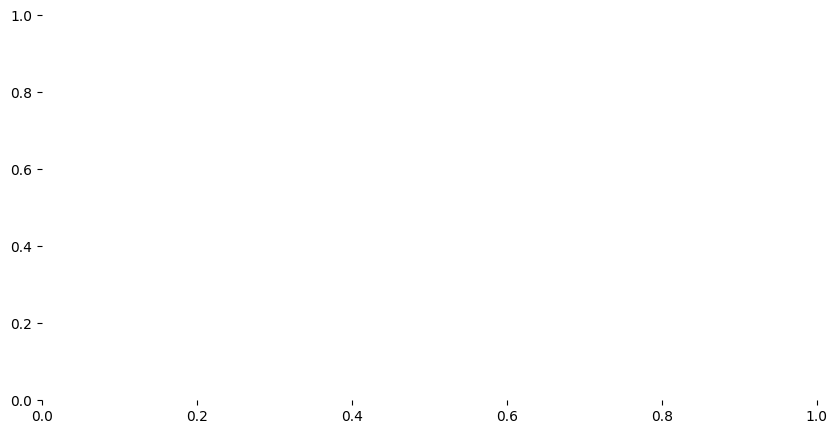

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. AGREGACIÓN POR MES Y GRUPO
# =========================
df_res = (
    df_4
    .groupby(["codmes", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# =========================
# 2. EFECTIVIDAD
# =========================
df_res["efectividad"] = df_res["suma_target_m"] / df_res["cantidad_casos"]

# =========================
# 3. TABLA DE RESULTADOS (LEGIBLE)
# =========================
df_view = df_res.copy()
df_view["efectividad_pct"] = (df_view["efectividad"] * 100).round(2)

print(
    df_view
    .sort_values(["codmes", "grupo_alerta"])
    [["codmes", "grupo_alerta", "cantidad_casos", "suma_target_m", "efectividad_pct"]]
)

# =========================
# 4. PIVOT PARA INSIGHT
# =========================
pivot_efectividad = (
    df_res
    .pivot(index="grupo_alerta", columns="codmes", values="efectividad")
    * 100
).round(2)

print("\nEfectividad (%) por grupo y mes")
print(pivot_efectividad)

# =========================
# 5. HEATMAP (VISUAL)
# =========================
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_efectividad,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Efectividad por Grupo de Alerta y Mes")
plt.ylabel("Grupo de Alerta")
plt.xlabel("Mes Base")
plt.tight_layout()
plt.show()

    codmes grupo_alerta  cantidad_casos  suma_target_m  efectividad_pct
0   202508           P1             135             80            59.26
1   202508           P2              86             14            16.28
2   202508           P3             103             13            12.62
3   202508        P4+P5             236              9             3.81
4   202509           P1             161             62            38.51
5   202509           P2             168             18            10.71
6   202509           P3             170             13             7.65
7   202509        P4+P5             315              4             1.27
8   202510           P1             296             99            33.45
9   202510           P2             308             18             5.84
10  202510           P3             296              2             0.68
11  202510        P4+P5             559             10             1.79
12  202511           P1              87             31          

TypeError: Image data of dtype object cannot be converted to float

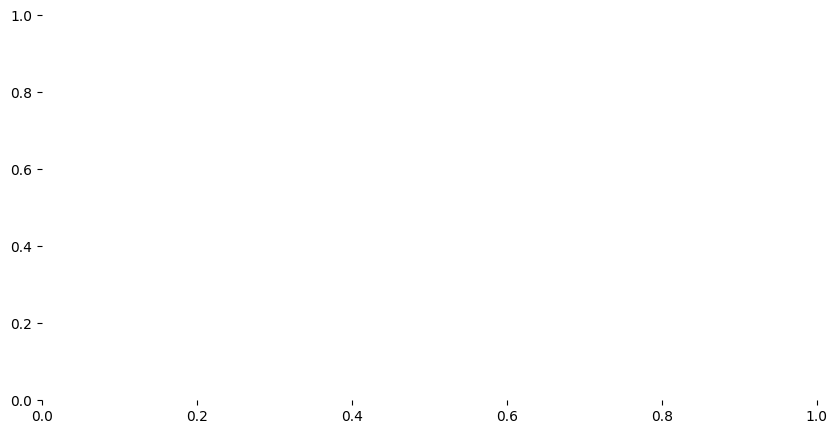

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. AGREGACIÓN POR MES Y GRUPO
# =========================
df_res = (
    df_5
    .groupby(["codmes", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# =========================
# 2. EFECTIVIDAD
# =========================
df_res["efectividad"] = df_res["suma_target_m"] / df_res["cantidad_casos"]

# =========================
# 3. TABLA DE RESULTADOS (LEGIBLE)
# =========================
df_view = df_res.copy()
df_view["efectividad_pct"] = (df_view["efectividad"] * 100).round(2)

print(
    df_view
    .sort_values(["codmes", "grupo_alerta"])
    [["codmes", "grupo_alerta", "cantidad_casos", "suma_target_m", "efectividad_pct"]]
)

# =========================
# 4. PIVOT PARA INSIGHT
# =========================
pivot_efectividad = (
    df_res
    .pivot(index="grupo_alerta", columns="codmes", values="efectividad")
    * 100
).round(2)

print("\nEfectividad (%) por grupo y mes")
print(pivot_efectividad)

# =========================
# 5. HEATMAP (VISUAL)
# =========================
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_efectividad,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Efectividad por Grupo de Alerta y Mes")
plt.ylabel("Grupo de Alerta")
plt.xlabel("Mes Base")
plt.tight_layout()
plt.show()


In [38]:
df_res = (
    df_5
    .groupby(["mes_base", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# Efectividad
df_res["efectividad"] = (
    df_res["suma_target_m"] / df_res["cantidad_casos"]
)


KeyError: 'mes_base'

In [39]:
df_res["efectividad_pct"] = df_res["efectividad"] * 100

KeyError: 'efectividad'

In [40]:
df_efec_p13 = (
    df_res[df_res["grupo_alerta"].isin(["P1", "P2", "P3"])]
    .groupby("mes_base")
    .agg(efectividad_prom=("efectividad", "mean"))
    .reset_index()
)


KeyError: 'mes_base'

In [41]:
df_res.sort_values(["mes_base", "grupo_alerta"])


KeyError: 'mes_base'

In [9]:
df_all = pd.concat([df_2, df_1], ignore_index=True)

In [10]:
# =================================================================
# CANTIDAD DE CLIENTES POR MES EN CADA GRUPO
# =================================================================
print("="*70)
print("CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5")
print("="*70)

# Aseguramos tipos correctos
df_all['codmes'] = df_all['codmes'].astype(str)
df_all['score'] = pd.to_numeric(df_all['score'], errors='coerce')

# Recalculamos grupo_corte_0.5 por si acaso
df_all['grupo_corte_0.5'] = (df_all['score'] > 0.5).astype(int)

# Convertimos grupo_alerta a número si es string
if df_all['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping)
else:
    df_all['grupo_alerta_num'] = pd.to_numeric(df_all['grupo_alerta'], errors='coerce')

# Tabla final: cantidad por mes y grupo
tabla = df_all.groupby('codmes').agg(
    Total_Clientes=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).reset_index()

# Ordenar meses
tabla = tabla.sort_values('codmes')

print(tabla.to_string(index=False))

CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5
codmes  Total_Clientes  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202508          161572             466            580     1248     2504   319486


In [48]:
df_all_1= df_all[(df_all.variable1 !='0')]
df_all_2= df_all_1[(df_all_1.variable1 !=0)]
# =================================================================
# CANTIDAD POR MES - SOLO CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
# =================================================================
print("="*80)
print("CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')")
print("="*80)

# Filtrar solo clientes con historial de alerta
df_con_alerta = df_all_2[df_all_2['variable1'].astype(str) != '0'].copy()

# Aseguramos tipos
df_con_alerta['codmes'] = df_con_alerta['codmes'].astype(str)
df_con_alerta['score'] = pd.to_numeric(df_con_alerta['score'], errors='coerce')
df_con_alerta['grupo_corte_0.5'] = (df_con_alerta['score'] > 0.5).astype(int)

# Convertir grupo_alerta a número si es necesario
if df_con_alerta['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_con_alerta['grupo_alerta_num'] = df_con_alerta['grupo_alerta'].map(mapping)
else:
    df_con_alerta['grupo_alerta_num'] = pd.to_numeric(df_con_alerta['grupo_alerta'], errors='coerce')

# Tabla final
tabla_filtrada = df_con_alerta.groupby('codmes').agg(
    Total_Con_Alerta=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).astype(int).reset_index()

tabla_filtrada = tabla_filtrada.sort_values('codmes')
print(tabla_filtrada.to_string(index=False))



CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
codmes  Total_Con_Alerta  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202508               549              85            103      108      112      230
202512               435              39             49       82      112      193


In [54]:
# ========================================
# Crear stats por mes (para variación)
# ========================================
stats = (
    df_all
    .groupby('codmes')
    .agg(
        total=('score', 'count'),
        pct_mayor_05=('score', lambda x: (x > 0.5).mean() * 100)
    )
)

print("\n=== STATS POR MES ===")
print(stats)


=== STATS POR MES ===
         total  pct_mayor_05
codmes                      
202508  161909      0.143908
202512  165400      0.167473


In [55]:
print("\n=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===")

def psi(expected, actual, buckets=10):
    expected_perc = np.histogram(expected, bins=buckets, range=(0,1))[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets, range=(0,1))[0] / len(actual)
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    psi_value = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi_value

# Usamos el primer mes como referencia
mes_ref = df_all['codmes'].min()
ref_scores = df_all[df_all['codmes'] == mes_ref]['score']

psi_results = []
for mes in sorted(df_all['codmes'].unique()):
    if mes == mes_ref:
        psi_results.append({'codmes': mes, 'PSI': 0.0, 'var_pct_mayor05': 0.0})
        continue
    actual_scores = df_all[df_all['codmes'] == mes]['score']
    psi_val = psi(ref_scores, actual_scores)
    var_pct = (stats.loc[mes, 'pct_mayor_05'] / stats.loc[mes_ref, 'pct_mayor_05'] - 1) * 100
    psi_results.append({'codmes': mes, 'PSI': round(psi_val, 4), 'var_pct_mayor05': round(var_pct, 2)})

psi_df = pd.DataFrame(psi_results)
print(psi_df)

# Interpretación automática
print("\nInterpretación PSI:")
for _, row in psi_df.iterrows():
    if row['PSI'] < 0.1:
        print(f"{row['codmes']}: PSI = {row['PSI']} → ESTABLE")
    elif row['PSI'] < 0.25:
        print(f"{row['codmes']}: PSI = {row['PSI']} → Monitorear")
    else:
        print(f"{row['codmes']}: PSI = {row['PSI']} → INESTABLE (revisar modelo)")


=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===
   codmes     PSI  var_pct_mayor05
0  202508  0.0000             0.00
1  202512  0.0002            16.37

Interpretación PSI:
202508: PSI = 0.0 → ESTABLE
202512: PSI = 0.0002 → ESTABLE


In [11]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers.csv"
train_path        = f"{base_s3_path}/train.csv"
val_path          = f"{base_s3_path}/validation.csv"
test_path         = f"{base_s3_path}/test.csv"
extras_val_path   = f"{base_s3_path}/extras_validation.csv"
extras_test_path  = f"{base_s3_path}/extras_test.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['num_documento', 'mes_base']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['num_documento', 'mes_base']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['num_documento', 'mes_base', 'target']].head())


Se cargaron 31 variables desde S3
Primeras 10 variables: ['target', 'codunico', 'codmes_lag1', 'pasivo_soles', 'trx_monto_abonos_6m_efectivo', 'trx_monto_cargos_6m_efectivo', 'trx_monto_cargos_promedio_3m_total', 'trx_monto_abonos_3m_max', 'trx_q_cargos_3m_total', 'trx_q_abonos_promedio_3m_total']

Shapes cargados desde S3:
  Train : (113900, 31)
  Val   : (56100, 31)
  Test  : (644322, 31)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 33 columnas (incluye num_documento y mes_base)
df_test ahora tiene 33 columnas


,num_documento,mes_base,target
0,F14E0C7F3F2C493C605C00BA468619460B8E4AE71D1129...,202504.0,0.0
1,48144837D226CEF4F133315DF7C5F2A06B5F7F41A6FBC9...,202507.0,0.0
2,F23D144F5D73C9EEF079DFF7056AAE896D9A80A01AF334...,202503.0,0.0
3,7C197505491ACCCB3E86EC34174F2B614F96DF16F9CA74...,202505.0,0.0
4,78AE54B841EFD3444DA4FE8884150663FD287ACE383949...,202502.0,0.0


In [12]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [13]:
# Cantidad de casos con score > 0.5 por mes
conteo_mayor_05 = df_2[df_2["score"] > 0.5] \
                     .groupby("codmes") \
                     .size()

print(conteo_mayor_05)

Series([], dtype: int64)


In [14]:
df_test.mes_base.value_counts()

mes_base
202511.0    163556
202510.0    161893
202509.0    160124
202508.0    158749
Name: count, dtype: int64

In [15]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [16]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [17]:
df_test['codmes']= df_test.mes_base.astype('int64')

In [18]:
df_3 = pd.merge(df_2, df_test, left_on=['num_documento','codmes'], right_on=['num_documento','codmes'], how='inner')

In [19]:
df_3.head()

,codmes,num_documento,codunico_x,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,...,sectorista_id,ciiu_v4,flag_casos_hist,flag_variacion_abono_monto_total_5m_1m,flag_variacion_efect_cargos_monto_5m_1m,q_ro_debajo_umbral,q_alerta_hist,q_ros_hist,tipo_alerta_n2,mes_base
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,...,64,250,0,0,0,0.0,0.0,0.0,0,202508.0
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,...,398,193,0,1,0,0.0,0.0,0.0,0,202508.0
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,...,398,176,0,0,0,0.0,0.0,0.0,0,202508.0
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,...,427,250,0,0,0,0.0,0.0,0.0,0,202508.0
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,...,398,250,0,0,0,0.0,0.0,0.0,0,202508.0


In [20]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

In [21]:
df_5=df_3

In [22]:
df_5[["target"]].value_counts()

target
0.0       158636
1.0          112
Name: count, dtype: int64

In [23]:
y_test=df_5.target

In [24]:
y_test['prob'] = df_5.score
y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

/tmp/ipykernel_11310/1092124540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = df_5.score


In [25]:
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')

In [26]:
Tabla_Deciles(df_5['target'],y_test['prob'],n=10)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.0009999729, 8.71e-07]",15853,22,0.001386,0.099933,1.000000,15853,112
"(8.71e-07, 1.27e-06]",15863,18,0.001133,0.199929,0.803571,31716,90
"(1.27e-06, 1.83e-06]",15948,16,0.001002,0.300461,0.642857,47664,72
"(1.83e-06, 2.5e-06]",15823,21,0.001325,0.400206,0.500000,63487,56
"(2.5e-06, 2.92e-06]",15861,1,0.000063,0.500189,0.312500,79348,35
"(2.92e-06, 3.82e-06]",15813,10,0.000632,0.599870,0.303571,95161,34
"(3.82e-06, 4.93e-06]",19158,7,0.000365,0.720637,0.214286,114319,24
"(4.93e-06, 6.29e-06]",12658,8,0.000632,0.800430,0.151786,126977,17
"(6.29e-06, 1.22e-05]",15878,9,0.000567,0.900521,0.080357,142855,9


In [27]:
Tabla_Deciles(df_5['target'],y_test['prob'],n=1000)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-7.294701999999999e-08, 3.629477e-07]",159,0,0.000000,0.001002,1.000000,159,112
"(3.629477e-07, 4.129221e-07]",163,1,0.006098,0.002030,1.000000,322,112
"(4.129221e-07, 4.413831e-07]",154,0,0.000000,0.003001,0.991071,476,111
"(4.413831e-07, 4.696738e-07]",202,2,0.009804,0.004274,0.991071,678,111
"(4.696738e-07, 4.825923e-07]",121,0,0.000000,0.005037,0.973214,799,109
...,...,...,...,...,...,...,...
"(3.773114e-05, 3.901827e-05]",159,0,0.000000,0.996010,0.000000,158003,0
"(3.901827e-05, 4.058293e-05]",157,0,0.000000,0.996999,0.000000,158160,0
"(4.058293e-05, 4.230275e-05]",158,0,0.000000,0.997995,0.000000,158318,0


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(df_5.target,  y_test.prob)
roc_auc = auc(fpr, tpr)
print('Ensemble Area under the ROC curve test : %f' % roc_auc)
print('Ensemble Gini value test : %f' % ((roc_auc*2-1)*100))

Ensemble Area under the ROC curve test : 0.343344
Ensemble Gini value test : -31.331273


In [29]:
test_data_0825_alerta= df_5[(df_5.variable1 !='0')]

In [30]:
test_data_0825_alerta_1= test_data_0825_alerta[(test_data_0825_alerta.variable1 !=0)]

In [31]:
df_res = test_data_0825_alerta_1.groupby('grupo_alerta').agg({'num_documento':len}).reset_index()
df_res

,grupo_alerta,num_documento
0,P4+P5,540


In [32]:
test_data_0825_alerta_1.shape

(540, 44)

In [33]:
y_test=test_data_0825_alerta_1.target

In [34]:
y_test.shape

(540,)

In [35]:
y_test['prob'] = test_data_0825_alerta_1.score
#y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

/tmp/ipykernel_11310/3435642817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = test_data_0825_alerta_1.score
/tmp/ipykernel_11310/3435642817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = test_data_0825_alerta_1.score


In [36]:
y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')

/tmp/ipykernel_11310/1756741874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')
/tmp/ipykernel_11310/1756741874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')


In [37]:
Tabla_Deciles(test_data_0825_alerta_1['target'],test_data_0825_alerta_1['score'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.0009999728, 7.46e-07]",96,13,0.119266,0.224299,1.000000,96,112
"(7.46e-07, 9.8e-07]",94,13,0.121495,0.443925,0.883929,190,99
"(9.8e-07, 1.32e-06]",94,14,0.129630,0.663551,0.767857,284,86
"(1.32e-06, 2.76e-06]",70,38,0.351852,0.827103,0.642857,354,72
"(2.76e-06, 1.88e-05]",74,34,0.314815,1.000000,0.303571,428,34


In [292]:
# Control puntos de cortes

In [103]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202507.txt'.format(bucket_name, model_prefix ), sep= '|')


/tmp/ipykernel_12044/391166737.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202507.txt'.format(bucket_name, model_prefix ), sep= '|')


In [104]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202508.txt'.format(bucket_name, model_prefix ), sep= '|')

/tmp/ipykernel_12044/2266279170.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202508.txt'.format(bucket_name, model_prefix ), sep= '|')


In [105]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df_2 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202509.txt'.format(bucket_name, model_prefix ), sep= '|')

/tmp/ipykernel_12044/1973552465.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202509.txt'.format(bucket_name, model_prefix ), sep= '|')


In [106]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202509,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF6...,21728054,plaft_pj_minorista,20251216,P1,1,0.998502,1,0,NaN,NaN
1,202509,493EB0F435E8A85CEFAAB1C42570719DC72992E0DBDC1F...,21723470,plaft_pj_minorista,20251216,P1,1,0.996069,2,AUTOMATICA,NaN,NaN
2,202509,31AA4CC07FDAE1DB5043CCD1C2FCECC49D9DD698C08846...,21739949,plaft_pj_minorista,20251216,P1,1,0.994686,3,AUTOMATICA,NaN,NaN
3,202509,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4...,21678782,plaft_pj_minorista,20251216,P1,1,0.992375,4,0,NaN,NaN
4,202509,B806D2CF15413A25776F325812DC9B2F7C041A5AA86688...,21704502,plaft_pj_minorista,20251216,P1,1,0.992273,5,0,NaN,NaN


In [107]:
df_1.head(10)

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,B806D2CF15413A25776F325812DC9B2F7C041A5AA86688...,21704502,plaft_pj_minorista,20251216,P1,1,0.997901,1,0,NaN,NaN
1,202508,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF6...,21728054,plaft_pj_minorista,20251216,P1,1,0.996828,2,AUTOMATICA,NaN,NaN
2,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4...,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN
3,202508,5D3E7AB553786651888B36DB6049E33680C6A55575A773...,21651580,plaft_pj_minorista,20251216,P1,1,0.996186,4,0,NaN,NaN
4,202508,CC51D6B3F3BF2996D78E05E7C5054FB7406328D647F441...,21665571,plaft_pj_minorista,20251216,P1,1,0.995613,5,AUTOMATICA,NaN,NaN
5,202508,8F7CB8110C300F765DDB9F30A0F77E153FE63389DEBB2B...,21066636,plaft_pj_minorista,20251216,P1,1,0.994143,6,AUTOMATICA,NaN,NaN
6,202508,250CDDB7A2E7F170375768A978ADCFA3E5358D2F1DD4A1...,21570669,plaft_pj_minorista,20251216,P1,1,0.994007,7,MANUAL,NaN,NaN
7,202508,12BBAB56EDAA2EED1FF1586740E73B8F450D4C67795D7B...,21687542,plaft_pj_minorista,20251216,P1,1,0.992973,8,AUTOMATICA,NaN,NaN
8,202508,00E5CF5595BCE6D77598FEE3DA207F5352FB52D7D58EAA...,21563570,plaft_pj_minorista,20251216,P1,1,0.992716,9,AUTOMATICA,NaN,NaN
9,202508,93F5B3C013178B5FFDEF444A8124091C3531752453BC73...,21618417,plaft_pj_minorista,20251216,P1,1,0.990426,10,SEMI AUTOMATICA,NaN,NaN


In [108]:
df_all = pd.concat([df, df_1, df_2], ignore_index=True)

In [109]:
df_all.codmes.value_counts()

codmes
202509    163574
202508    161909
202507    160139
Name: count, dtype: int64

In [110]:
df_all["grupo_corte_0.5"].value_counts()

grupo_corte_0.5
0    484920
1       702
Name: count, dtype: int64

In [111]:
# Cantidad de casos con score > 0.5 por mes
conteo_mayor_05 = df_all[df_all["score"] > 0.5] \
                     .groupby("codmes") \
                     .size()

print(conteo_mayor_05)

codmes
202507    218
202508    233
202509    251
dtype: int64


In [114]:
# =================================================================
# CANTIDAD DE CLIENTES POR MES EN CADA GRUPO
# =================================================================
print("="*70)
print("CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5")
print("="*70)

# Aseguramos tipos correctos
df_all['codmes'] = df_all['codmes'].astype(str)
df_all['score'] = pd.to_numeric(df_all['score'], errors='coerce')

# Recalculamos grupo_corte_0.5 por si acaso
df_all['grupo_corte_0.5'] = (df_all['score'] > 0.5).astype(int)

# Convertimos grupo_alerta a número si es string
if df_all['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping)
else:
    df_all['grupo_alerta_num'] = pd.to_numeric(df_all['grupo_alerta'], errors='coerce')

# Tabla final: cantidad por mes y grupo
tabla = df_all.groupby('codmes').agg(
    Total_Clientes=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).reset_index()

# Ordenar meses
tabla = tabla.sort_values('codmes')

print(tabla.to_string(index=False))

CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5
codmes  Total_Clientes  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202507          159797             218            276      621     1243   157999
202508          161572             233            290      624     1252   159743
202509          163265             251            351      725     1274   161224


In [115]:
df_all_1= df_all[(df_all.variable1 !='0')]

In [116]:
df_all_2= df_all_1[(df_all_1.variable1 !=0)]

In [123]:
# =================================================================
# CANTIDAD POR MES - SOLO CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
# =================================================================
print("="*80)
print("CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')")
print("="*80)

# Filtrar solo clientes con historial de alerta
df_con_alerta = df_all_2[df_all_2['variable1'].astype(str) != '0'].copy()

# Aseguramos tipos
df_con_alerta['codmes'] = df_con_alerta['codmes'].astype(str)
df_con_alerta['score'] = pd.to_numeric(df_con_alerta['score'], errors='coerce')
df_con_alerta['grupo_corte_0.5'] = (df_con_alerta['score'] > 0.5).astype(int)

# Convertir grupo_alerta a número si es necesario
if df_con_alerta['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_con_alerta['grupo_alerta_num'] = df_con_alerta['grupo_alerta'].map(mapping)
else:
    df_con_alerta['grupo_alerta_num'] = pd.to_numeric(df_con_alerta['grupo_alerta'], errors='coerce')

# Tabla final
tabla_filtrada = df_con_alerta.groupby('codmes').agg(
    Total_Con_Alerta=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).astype(int).reset_index()

tabla_filtrada = tabla_filtrada.sort_values('codmes')
print(tabla_filtrada.to_string(index=False))

CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
codmes  Total_Con_Alerta  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202507               536              84             95      103      119      220
202508               549              85            103      108      112      230
202509               792              71             92      161      173      366


In [433]:
print("\n=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===")

def psi(expected, actual, buckets=10):
    expected_perc = np.histogram(expected, bins=buckets, range=(0,1))[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets, range=(0,1))[0] / len(actual)
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    psi_value = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi_value

# Usamos el primer mes como referencia
mes_ref = df_all['codmes'].min()
ref_scores = df_all[df_all['codmes'] == mes_ref]['score']

psi_results = []
for mes in sorted(df_all['codmes'].unique()):
    if mes == mes_ref:
        psi_results.append({'codmes': mes, 'PSI': 0.0, 'var_pct_mayor05': 0.0})
        continue
    actual_scores = df_all[df_all['codmes'] == mes]['score']
    psi_val = psi(ref_scores, actual_scores)
    var_pct = (stats.loc[mes, 'pct_mayor_05'] / stats.loc[mes_ref, 'pct_mayor_05'] - 1) * 100
    psi_results.append({'codmes': mes, 'PSI': round(psi_val, 4), 'var_pct_mayor05': round(var_pct, 2)})

psi_df = pd.DataFrame(psi_results)
print(psi_df)

# Interpretación automática
print("\nInterpretación PSI:")
for _, row in psi_df.iterrows():
    if row['PSI'] < 0.1:
        print(f"{row['codmes']}: PSI = {row['PSI']} → ESTABLE")
    elif row['PSI'] < 0.25:
        print(f"{row['codmes']}: PSI = {row['PSI']} → Monitorear")
    else:
        print(f"{row['codmes']}: PSI = {row['PSI']} → INESTABLE (revisar modelo)")


=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===
   codmes     PSI  var_pct_mayor05
0  202507  0.0000             0.00
1  202508  0.0001             8.62
2  202509  0.0003            13.00

Interpretación PSI:
202507: PSI = 0.0 → ESTABLE
202508: PSI = 0.0001 → ESTABLE
202509: PSI = 0.0003 → ESTABLE


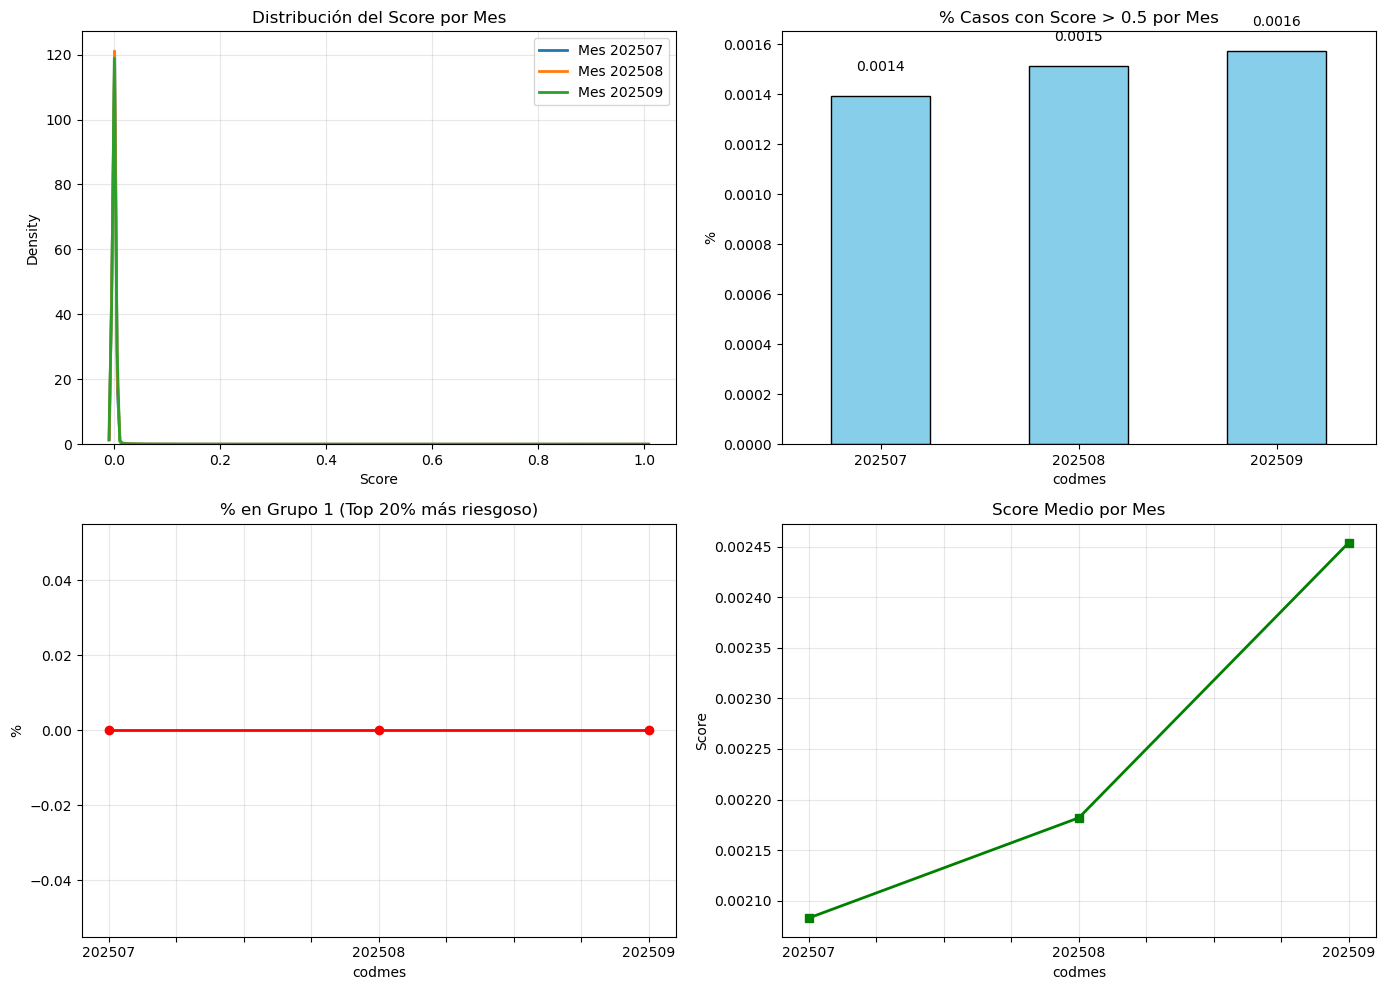

In [434]:
plt.figure(figsize=(14, 10))

# 3.1 Distribución del score por mes
plt.subplot(2, 2, 1)
for mes in sorted(df_all['codmes'].unique()):
    data_mes = df_all[df_all['codmes'] == mes]['score']
    sns.kdeplot(data_mes, label=f'Mes {mes}', linewidth=2)
plt.title('Distribución del Score por Mes')
plt.xlabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# 3.2 % de casos > 0.5 por mes
plt.subplot(2, 2, 2)
stats['pct_mayor_05'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('% Casos con Score > 0.5 por Mes')
plt.ylabel('%')
plt.xticks(rotation=0)
for i, v in enumerate(stats['pct_mayor_05']):
    plt.text(i, v + 0.0001, f"{v:.4f}", ha='center')

# 3.3 Top 20% (grupo_alerta == 1)
plt.subplot(2, 2, 3)
stats['pct_grupo_1'].plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('% en Grupo 1 (Top 20% más riesgoso)')
plt.ylabel('%')
plt.grid(True, alpha=0.3)

# 3.4 Score medio por mes
plt.subplot(2, 2, 4)
stats['score_medio'].plot(kind='line', marker='s', color='green', linewidth=2)
plt.title('Score Medio por Mes')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
print("="*90)
print("MIGRACIÓN DE CLIENTES ENTRE GRUPOS DE ALERTA - VERSIÓN FINAL")
print("="*90)

df_all['codmes'] = df_all['codmes'].astype(str)
df_all['num_documento'] = df_all['num_documento'].astype(str)

# CORRECTO: mapeo de strings a números
mapping = {
    'P1': 1, 'P2': 2, 'P3': 3, 'P4+P5': 4, 
    'Top 20% más riesgoso': 1, '2do 20%': 2, '3ro 20%': 3, '4to 20%': 4, 'Bottom 20%': 5
}
df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping).fillna(99).astype(int)

# Ver cuántos quedaron bien
print(f"Clientes con grupo válido: {(df_all['grupo_alerta_num'] != 99).sum():,}")
print(f"Clientes sin grupo (99): {(df_all['grupo_alerta_num'] == 99).sum():,}\n")

# Pivot
pivot = df_all.pivot_table(index='num_documento', columns='codmes', values='grupo_alerta_num', aggfunc='first')
pivot = pivot.dropna(thresh=2)
print(f"Clientes en al menos 2 meses: {len(pivot):,}\n")

# Migración mes a mes
meses = sorted(pivot.columns)
for i in range(len(meses)-1):
    mes1, mes2 = meses[i], meses[i+1]
    print(f"--- Migración {mes1} → {mes2} ---")
    
    data = pivot[[mes1, mes2]].dropna()
    data = data[(data[mes1] != 99) & (data[mes2] != 99)]
    
    if len(data) == 0:
        print("  → No hay clientes con grupo válido\n")
        continue
    
    migracion = pd.crosstab(data[mes1], data[mes2], margins=True, margins_name="Total →")
    
    # Solo grupos reales
    grupos = sorted(data[mes1].unique())
    grupos = [g for g in grupos if g != 99]
    filas = grupos + ['Total →']
    columnas = grupos + ['Total →']
    migracion = migracion.loc[filas, columnas]
    
    # Nombres bonitos
    nombres = {1: 'P1', 2: 'P2', 3: 'P3', 4: 'P4+P5'}
    migracion.rename(index=nombres, columns=nombres, inplace=True)
    
    print(migracion)
    
    estables = np.diag(migracion.iloc[:-1, :-1]).sum()
    total = migracion.iloc[:-1, -1].sum()
    print(f"  → Estables: {estables:,} ({100*estables/total:.2f}%)")
    print(f"  → Migraron: {total - estables:,}\n")

MIGRACIÓN DE CLIENTES ENTRE GRUPOS DE ALERTA - VERSIÓN FINAL
Clientes con grupo válido: 485,622
Clientes sin grupo (99): 0

Clientes en al menos 2 meses: 161,639

--- Migración 202507 → 202508 ---
202508    P1   P2    P3   P4+P5  Total →
202507                                  
P1       177   72    22       3      274
P2        69  344   169      35      617
P3        25  145   715     347     1232
P4+P5     18   59   340  154273   154690
Total →  289  620  1246  154658   156813
  → Estables: 155,509 (99.17%)
  → Migraron: 1,304

--- Migración 202508 → 202509 ---
202509    P1   P2    P3   P4+P5  Total →
202508                                  
P1       200   67    15       8      290
P2        87  368   133      21      609
P3        21  207   704     306     1238
P4+P5     39   74   417  155636   156166
Total →  347  716  1269  155971   158303
  → Estables: 156,908 (99.12%)
  → Migraron: 1,395



In [76]:
variables_importantes = ['codmes','codunico',	'modelo',	'fec_replica',	'grupo_alerta',	'grupo_corte_0.5',	'score',
"antiguedad",
    "pasivo_soles",                         
 "trx_monto_cargos_6m_efectivo",
                          "trx_q_abonos_ratio_3m_efectivo_total",
                             "q_meses_ingresos_0"
 
]

In [77]:
test_data_0825_sinalerta = df_5[(df_5["variable1"] == '0') | (df_5["variable1"] == 0)
]

In [78]:
test_data_0825_sinalerta_1 = test_data_0825_sinalerta[variables_importantes]

In [79]:
import pandas as pd

pd.set_option('display.max_columns', None)

test_data_0825_sinalerta_1.head(10)

,codmes,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,antiguedad,pasivo_soles,trx_monto_cargos_6m_efectivo,trx_q_abonos_ratio_3m_efectivo_total,q_meses_ingresos_0
0,202508,21704502,plaft_pj_minorista,20251216,P1,1,0.997901,0.0,5.1400,2525186.0,0.8362,9.0
4,202508,21651580,plaft_pj_minorista,20251216,P1,1,0.996186,0.0,52.2473,10582.0,0.0000,9.0
14,202508,21471280,plaft_pj_minorista,20251216,P1,1,0.981914,0.0,0.7000,1963988.8,0.9683,6.0
18,202508,21586985,plaft_pj_minorista,20251216,P1,1,0.975909,0.0,41.2888,34468.9,0.0000,8.0
19,202508,21494933,plaft_pj_minorista,20251216,P1,1,0.974184,0.0,0.0000,536150.0,0.9706,6.0
21,202508,21475150,plaft_pj_minorista,20251216,P1,1,0.968432,0.0,15.7700,6685193.5,0.9516,6.0
25,202508,21590241,plaft_pj_minorista,20251216,P1,1,0.965427,0.0,1169.0414,0.0,0.0000,7.0
27,202508,21555981,plaft_pj_minorista,20251216,P1,1,0.962985,0.0,14970.2800,3456329.0,0.8596,6.0
32,202508,21568076,plaft_pj_minorista,20251216,P1,1,0.956279,0.0,76.7171,15739.4,0.0000,7.0
34,202508,21564628,plaft_pj_minorista,20251216,P1,1,0.955159,0.0,0.0000,1070820.0,0.0000,11.0


In [50]:
 df_3[(df_3["target"] == 1)]

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3,target,pasivo_soles,trx_monto_abonos_6m_efectivo,trx_monto_cargos_6m_efectivo,trx_q_cargos_3m_total,trx_q_abonos_promedio_3m_total,trx_monto_cargos_promedio_3m_total,trx_q_abonos_ratio_1m_efectivo_total,trx_q_abonos_ratio_3m_efectivo_total,trx_q_abonos_ratio_9m_efectivo_total,trx_monto_cargos_ratio_1m_efectivo_total,trx_monto_abonos_3m_max,edad_constitucion,antiguedad,nivel_riesgo_lsb_total,q_meses_ingresos_0,q_meses_egresos_0,provincia,departamento,ubigeo_cd,sectorista_id,ciiu_v4,flag_casos_hist,flag_variacion_abono_monto_total_5m_1m,flag_variacion_efect_cargos_monto_5m_1m,q_ro_debajo_umbral,q_alerta_hist,q_ros_hist,mes_base,tipo_alerta_n2
1,202508,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF61FC7777601E18D59A5,21728054,plaft_pj_minorista,20251216,P1,1,0.996828,2,AUTOMATICA,NaN,NaN,1.0,722914.2000,0.0,43233.5,185.0,13.00,1.00,0.0000,0.0000,0.0000,0.0002,33967068.00,0.0,0.0,-1.0,10.0,10.0,163,21,644,500,317,0,1,0,0.0,24.0,0.0,202508.0,AUTOMATICA
2,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4E4740A2ADEDE94F9F1,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN,1.0,9.6600,5253841.5,2596149.5,685.0,134.67,19.00,0.9905,0.9629,0.9629,0.3708,2325261.20,-1.0,0.0,-1.0,9.0,9.0,29,7,1080,437,393,0,0,0,0.0,2.0,0.0,202508.0,MANUAL
3,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4E4740A2ADEDE94F9F1,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN,1.0,9.6600,5253841.5,2596149.5,685.0,134.67,19.00,0.9905,0.9629,0.9629,0.3708,2325261.20,-1.0,0.0,-1.0,9.0,9.0,29,7,1080,437,393,0,0,0,0.0,2.0,0.0,202508.0,SEMI AUTOMATICA
5,202508,CC51D6B3F3BF2996D78E05E7C5054FB7406328D647F44152CF5F67313C62A0E7,21665571,plaft_pj_minorista,20251216,P1,1,0.995613,5,AUTOMATICA,NaN,NaN,1.0,4172.8906,0.0,0.0,41.0,4.33,0.00,0.0000,0.0000,0.0000,0.0000,6141190.00,0.0,0.0,-1.0,10.0,10.0,163,21,644,502,317,0,0,1,0.0,12.0,0.0,202508.0,AUTOMATICA
6,202508,8F7CB8110C300F765DDB9F30A0F77E153FE63389DEBB2B90173B55C82A9BD0C4,21066636,plaft_pj_minorista,20251216,P1,1,0.994143,6,AUTOMATICA,NaN,NaN,1.0,10421.4670,182631.0,940000.0,256.0,9.00,1.33,0.0000,0.3704,0.3704,0.0000,3726511.00,1.0,1.0,-1.0,9.0,9.0,113,15,312,437,318,0,0,0,0.0,1.0,0.0,202508.0,AUTOMATICA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5939,202508,0379A385168DFD6DDDAD8E88E265069E8BF10999AA3A9F955EACDDF95AB60799,11149692,plaft_pj_minorista,20251216,P4+P5,0,0.000640,5922,AUTOMATICA,NaN,NaN,1.0,677073.7000,0.0,11450.0,220.0,6.33,1.00,0.0000,0.0000,0.0000,0.0089,891047.10,21.0,16.0,1.0,0.0,0.0,183,13,174,511,209,0,0,0,0.0,7.0,0.0,202508.0,AUTOMATICA
6048,202508,E4FE93F83985CAC8DC086F9BF23AD9B264EB2CBBE720D569102E821DC4A47F4C,1488790,plaft_pj_minorista,20251216,P4+P5,0,0.000604,6031,AUTOMATICA,NaN,NaN,1.0,345779.6600,5473.9,0.0,168.0,7.33,0.00,0.0000,0.0455,0.0476,0.0000,985726.25,35.0,31.0,1.0,0.0,0.0,86,12,104,37,321,0,0,1,0.0,10.0,2.0,202508.0,AUTOMATICA
8015,202508,79331F4BBFFAB6A604636D2877AFCB983E7F40564DA7E7F57BFB6D2BD71FDA66,13489156,plaft_pj_minorista,20251216,P4+P5,0,0.000212,7997,MANUAL,NaN,NaN,1.0,80.7700,0.0,0.0,97.0,6.00,0.00,0.0000,0.0000,0.0000,0.0000,538253.25,12.0,11.0,1.0,0.0,0.0,113,15,321,27,313,0,0,1,0.0,8.0,0.0,202508.0,MANUAL
8538,202508,2292E77C79D2B44BC9320F6456BAB7FF6B678E87ED5BEC727E989EC0087151B3,17185602,plaft_pj_minorista,20251216,P4+P5,0,0.000157,8520,MANUAL,NaN,NaN,1.0,0.0000,0.0,0.0,0.0,0.00,0.00,0.0000,0.0000,0.0000,0.0000,0.00,5.0,5.0,1.0,12.0,12.0,178,17,417,395,218,0,0,0,0.0,1.0,0.0,202508.0,MANUAL


In [35]:
import numpy as np
import pandas as pd

def nivel_negocio(x, p20, p40, p60, p80):
    if pd.isna(x):
        return "sin dato"
    elif x <= p20:
        return "muy bajo"
    elif x <= p40:
        return "bajo"
    elif x <= p60:
        return "esperado"
    elif x <= p80:
        return "elevado"
    else:
        return "muy elevado"


df_top10 = test_data_0825_sinalerta.head(50).copy()

# Percentiles más suaves (mejor interpretación de negocio)
p = {}
vars_numericas = [
    "trx_monto_abonos_6m_efectivo",
    "trx_monto_cargos_6m_efectivo",
    "trx_q_cargos_3m_total",
    "trx_q_abonos_promedio_3m_total",
    "trx_monto_cargos_promedio_3m_total",
    "trx_monto_abonos_3m_max",
    "antiguedad"
]

for v in vars_numericas:
    p[v] = np.nanpercentile(test_data_0825_sinalerta[v], [20, 40, 60, 80])


def resumen_fila_negocio(row):
    return (
        f"Montos (ing/eg): "
        f"{nivel_negocio(row['trx_monto_abonos_6m_efectivo'], *p['trx_monto_abonos_6m_efectivo'])} / "
        f"{nivel_negocio(row['trx_monto_cargos_6m_efectivo'], *p['trx_monto_cargos_6m_efectivo'])} | "
        f"Frecuencia trx: "
        f"{nivel_negocio(row['trx_q_cargos_3m_total'], *p['trx_q_cargos_3m_total'])} | "
        f"Efectivo: "
        f"{'alto' if row['trx_q_abonos_ratio_3m_efectivo_total'] > 0.7 else 'esperado'} | "
        f"Antigüedad cliente: "
        f"{nivel_negocio(row['antiguedad'], *p['antiguedad'])} | "
        f"Alertas / ROS: "
        f"{'sin eventos relevantes' if row['q_ros_hist'] == 0 else 'con historial'}"
    )


df_top10["descripcion_patron"] = df_top10.apply(resumen_fila_negocio, axis=1)

df_top10[["codunico", "score", "descripcion_patron"]]



,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
4,21651580,0.996186,Montos (ing/eg): muy bajo / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
14,21471280,0.981914,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
18,21586985,0.975909,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
19,21494933,0.974184,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
32,21568076,0.956279,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
34,21564628,0.955159,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy bajo | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes


In [32]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df_top10[["codunico", "score", "descripcion_patron"]]


,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
4,21651580,0.996186,Montos (ing/eg): muy bajo / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
14,21471280,0.981914,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
18,21586985,0.975909,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
19,21494933,0.974184,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
32,21568076,0.956279,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
34,21564628,0.955159,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy bajo | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes


In [33]:
import numpy as np

# =========================
# 1. Funciones de niveles
# =========================

def nivel_monto(x):
    if pd.isna(x) or x <= 0:
        return "muy bajo"
    elif x < 1e5:
        return "bajo"
    elif x < 5e5:
        return "medio"
    elif x < 2e6:
        return "elevado"
    else:
        return "muy elevado"


def nivel_frecuencia(x):
    if pd.isna(x) or x == 0:
        return "muy baja"
    elif x < 10:
        return "baja"
    elif x < 50:
        return "media"
    elif x < 200:
        return "alta"
    else:
        return "muy alta"


def nivel_pasivo(x):
    if pd.isna(x) or x <= 0:
        return "sin pasivo"
    elif x < 1e5:
        return "muy bajo"
    elif x < 5e5:
        return "bajo"
    elif x < 2e6:
        return "medio"
    elif x < 1e7:
        return "alto"
    else:
        return "muy alto"


# =========================
# 2. Crear variables base
# =========================

df_top10 = df_top10.copy()

df_top10["nivel_ingresos"] = df_top10["trx_monto_abonos_6m_efectivo"].apply(nivel_monto)
df_top10["nivel_egresos"]  = df_top10["trx_monto_cargos_6m_efectivo"].apply(nivel_monto)
df_top10["nivel_frecuencia"] = df_top10["trx_q_cargos_3m_total"].apply(nivel_frecuencia)


# =========================
# 3. Construir descripción
# =========================

df_top10["descripcion_patron"] = (
    "Montos (ing/eg): "
    + df_top10["nivel_ingresos"]
    + " / "
    + df_top10["nivel_egresos"]
    + " | Frecuencia trx: "
    + df_top10["nivel_frecuencia"]
    + " | ROS: "
    + df_top10["q_ros_hist"].fillna(0).astype(int).astype(str)
    + " | Pasivo: "
    + df_top10["pasivo_soles"].apply(nivel_pasivo)
)


# =========================
# 4. Resultado final
# =========================

resultado = df_top10[
    ["codunico", "score", "descripcion_patron"]
].sort_values("score", ascending=False)

resultado


,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
4,21651580,0.996186,Montos (ing/eg): muy bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
14,21471280,0.981914,Montos (ing/eg): elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
18,21586985,0.975909,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
19,21494933,0.974184,Montos (ing/eg): muy elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: sin pasivo
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
32,21568076,0.956279,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
34,21564628,0.955159,Montos (ing/eg): elevado / elevado | Frecuencia trx: muy baja | ROS: 0 | Pasivo: sin pasivo


In [34]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df_top10[["codunico", "score", "descripcion_patron"]]

,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
4,21651580,0.996186,Montos (ing/eg): muy bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
14,21471280,0.981914,Montos (ing/eg): elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
18,21586985,0.975909,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
19,21494933,0.974184,Montos (ing/eg): muy elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: sin pasivo
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
32,21568076,0.956279,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
34,21564628,0.955159,Montos (ing/eg): elevado / elevado | Frecuencia trx: muy baja | ROS: 0 | Pasivo: sin pasivo


In [56]:
import pandas as pd

# Tus datos originales (pegados tal como los enviaste)
datos = """codmescodunicomodelofec_replicagrupo_alertagrupo_corte_0.5scoreantiguedadpasivo_solestrx_monto_cargos_6m_efectivotrx_q_abonos_ratio_3m_efectivo_totalq_meses_ingresos_0
02251221781964plaft_pj_minorista20251217P110.99841500.0000758385.00.981191
20251221781455plaft_pj_minorista20251217P110.99839900.0000725553.30.978793
20251221869624plaft_pj_minorista20251217P110.99332900.0000419883.01.0000114
20251221829911plaft_pj_minorista20251217P110.9892310535369.30790.00.615295
20251221788525plaft_pj_minorista20251217P110.98844102.85001394400.70.912387
20251221684706plaft_pj_minorista20251217P110.98017400.0000571530.40.947488
20251221518687plaft_pj_minorista20251217P110.98016500.00001331687.01.0000412
20251221683020plaft_pj_minorista20251217P110.97644203.7800878083.90.9359613
20251221737824plaft_pj_minorista20251217P110.97460500.0000339900.00.50001014
20251221797120plaft_pj_minorista20251217P110.97344700.00007900.00.05489"""

# Procesar los datos (están pegados sin separadores)
lineas = datos.split('\n')
filas = []
for linea in lineas[1:]:
    if not linea.strip():
        continue
    fila = {
        'score': float(linea[48:56]),
        'antiguedad': float(linea[56:64]),
        'pasivo_soles': float(linea[64:78]),
        'trx_monto_cargos_6m_efectivo': float(linea[78:89]),
        'trx_q_abonos_ratio_3m_efectivo_total': float(linea[89:97]),
        'q_meses_ingresos_0': int(linea[97:])
    }
    filas.append(fila)

# Crear DataFrame
df = pd.DataFrame(filas)

# Ordenar por score descendente
df = df.sort_values('score', ascending=False).reset_index(drop=True)
df['Fila'] = df.index  # Columna Fila como en la imagen

# Función para generar la Razón sospechosa (basada en patrones típicos de alerta)
def generar_razon_sospechosa(row):
    partes = []
    
    cargos = row['trx_monto_cargos_6m_efectivo']
    ratio_abonos = row['trx_q_abonos_ratio_3m_efectivo_total']
    pasivo = row['pasivo_soles']
    meses_sin_ing = row['q_meses_ingresos_0']
    antiguedad = row['antiguedad']

    # Patrón 1: Cargos altos en efectivo + pasivo bajo
    if cargos > 50000 and pasivo < 10000:
        partes.append("Cargos en efectivo muy altos con pasivo casi nulo")
    
    # Patrón 2: Ratio abonos alto + pasivo bajo → posible layering/colocación
    if ratio_abonos > 0.95 and pasivo < 10000:
        partes.append("Ratio de abonos en efectivo muy alto con pasivo bajo")
    
    # Patrón 3: Muchos meses sin ingresos
    if meses_sin_ing >= 8:
        partes.append(f"{meses_sin_ing} meses sin ingresos")
    
    # Patrón 4: Cargos altos pero ratio abonos bajo → movimientos circulares
    if cargos > 30000 and ratio_abonos < 0.4:
        partes.append("Cargos altos con bajo ratio de abonos → posible layering")
    
    # Patrón 5: Pasivo alto sin movimientos recientes de efectivo
    if pasivo > 100000 and cargos < 1000:
        partes.append("Pasivo alto sin movimientos recientes en efectivo")
    
    # Patrón 6: Cuenta nueva con actividad sospechosa
    if antiguedad < 100 and cargos > 40000:
        partes.append("Cuenta reciente con alta actividad en efectivo")
    
    if not partes:
        return "Revisar patrón de transacciones"
    
    return " + ".join(partes) + " → posible alerta PLAFT."

# Aplicar la función
df['Razon_sospechosa'] = df.apply(generar_razon_sospechosa, axis=1)

# Columnas finales como en la imagen
columnas_finales = [
    'Fila', 'score', 'pasivo_soles', 'trx_monto_cargos_6m_efectivo',
    'trx_q_abonos_ratio_3m_efectivo_total', 'q_meses_ingresos_0', 'Razon_sospechosa'
]

df_final = df[columnas_finales].copy()

# Formateo bonito
df_final['score'] = df_final['score'].round(6)
df_final['pasivo_soles'] = df_final['pasivo_soles'].round(2)
df_final['trx_monto_cargos_6m_efectivo'] = df_final['trx_monto_cargos_6m_efectivo'].round(2)
df_final['trx_q_abonos_ratio_3m_efectivo_total'] = df_final['trx_q_abonos_ratio_3m_efectivo_total'].round(6)

# Guardar en TXT
df_final.to_csv('top_sospechosos_plaft.txt', sep='\t', index=False, encoding='utf-8')

print("Archivo guardado como: top_sospechosos_plaft.txt")
print("\nVista previa de la tabla:")
print(df_final.to_string(index=False))

ValueError: could not convert string to float: '.00.981191'